# Assignment 2 – Zero-Shot Image Classification with Transformers

In this assignment, you will apply a pre-trained vision–language transformer (e.g. CLIP) to perform **zero-shot** classification on the Fashion-MNIST dataset—classifying each image without any task-specific training. You will build on the concepts from Assignment 1 by comparing this “off-the-shelf” approach to the CNN you previously trained.

You will:
1. **Load** the Fashion-MNIST images using PyTorch instead of Keras.
2. **Run a zero-shot baseline** with simple text prompts to set a performance reference.
3. **Engineer improved prompts** and measure the resulting accuracy gains.
4. **Visualise image embeddings** with UMAP to inspect class separability.
5. **Conduct one mini-experiment** of your choice.
6. **Summarise findings** and reflect on strengths and weaknesses of zero-shot transformers versus a trained CNN.

# 1. Loading the Fashion-MNIST Dataset

As in assignment 1, we'll load the Fashion-MNIST dataset, but this time using `torchvision.datasets` to ensure compatibility with the `transformers` library. We will also load our model and processor from the `transformers` library.

The transformers library allows us to use pre-trained models like CLIP, which can perform zero-shot classification by leveraging the text prompts we provide. There are two key objects we will use: the `CLIPModel` for the model itself and the `CLIPProcessor` for preparing our images and text prompts.

Since we are not actually training a model in this assignment, we will set the CLIP model to evaluation mode. If the model is designed to utilize features like dropout or batch normalization, setting it to evaluation mode ensures that these features behave correctly during inference (prediction). Setting the model to evaluaton mode also tells PyTorch that we don't have to compute gradients, which can save memory and speed up inference.

In order to speed up processing, we will also move the model to an "accelerator" if available. This is typically a GPU, but modern MacBooks also have an "Apple Silicon" accelerator that can be used for inference, called MPS (Metal Performance Shaders). If you are using a MacBook with Apple Silicon, you can use the MPS device for faster processing.

In [ ]:
# Uncomment and run if required
#!pip install transformers torchvision torch accelerate

In [1]:
from transformers import CLIPModel, CLIPProcessor
import torch

clip_model_name = "openai/clip-vit-base-patch32"
clip_model     = CLIPModel.from_pretrained(clip_model_name)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name, use_fast=False)

# Set model to evaluation mode, as we are not training it
clip_model.eval()

# Check for accelerators
device = "cpu" # Default to CPU
if torch.cuda.is_available():
    device = "cuda" # Use GPU if available
elif torch.backends.mps.is_available():
    device = "mps"

clip_model.to(device)

print(f"Using device: {device}")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Using device: mps


Now we are ready to load the testing set from Fashion-MNIST. We will use the `torchvision.datasets.FashionMNIST` class to load the dataset. We do not need to apply any transformations to the images, as the `CLIPProcessor` ensures any input images are in the format that the model is trained on.

You should:

- [ ] Use the `torchvision.datasets.FashionMNIST` class to load the *test* split of the dataset. Documentation is available [here](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- [ ] Create a PyTorch `DataLoader` to iterate over the dataset in batches. Use a batch size of 16 and set `shuffle=True` to randomise the order of the images. You will also need to supply the provided `collate_clip` function to the `DataLoader collate_fn` argument to ensure the images are processed correctly. Documentation for `DataLoader` is available [here](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader).

In [3]:
from torchvision import datasets
from torch.utils.data import DataLoader

CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

def collate_clip(batch):
    imgs, labels = zip(*batch) # Unzip the batch into images and labels
    proc = clip_processor(images=list(imgs),
                        return_tensors="pt",
                        padding=True) # Process images with CLIPProcessor
    # Send pixel_values to GPU/CPU now; labels stay on CPU for metrics
    return proc["pixel_values"].to(device), torch.tensor(labels)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_clip
)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.09MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 263kB/s]
100%|██████████| 4.42M/4.42M [00:04<00:00, 1.01MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.84MB/s]


If your code is correct, the following cell should show the first batch of images from the Fashion-MNIST dataset:

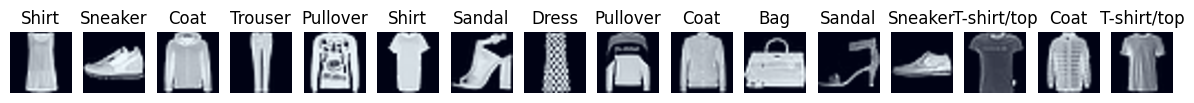

In [4]:
import matplotlib.pyplot as plt

# Display the first batch of images from `test_loader`

def show_batch(loader):
    images, labels = next(iter(loader))
    images = images.cpu()  # Move images to CPU for plotting
    # Renormalize to [0, 1] for visualization
    images = (images - images.min()) / (images.max() - images.min())
    _, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for ax, img, label in zip(axes, images, labels):
        ax.imshow(img.permute(1, 2, 0))
        ax.set_title(CLASS_NAMES[label.item()])
        ax.axis('off')
    plt.show()

show_batch(test_loader)

We’re now ready to run our zero-shot classification baseline!

# Brief Introduction to Zero-Shot Classification

In Assignment 1, we followed the typical machine-learning pipeline: we trained a CNN on the Fashion-MNIST dataset, using labelled examples to update the model’s weights. While effective, that approach requires a curated, task-specific training set—a luxury you don’t always have in practice.

Zero-shot classification flips the script.  A large vision–language model (VLM) such as **CLIP** is first pre-trained on hundreds of millions of image–text pairs scraped from the web.  Because it learns *joint* visual–textual embeddings, the model can later solve new tasks simply by “measuring” how similar an image is to a **text prompt** that describes each candidate class—without seeing a single task-labelled example.

**How it works**  
1. Feed an image through CLIP’s vision encoder → **image feature**.  
2. Feed a textual prompt (e.g. “a photo of a sandal”) through CLIP’s text encoder → **text feature**.  
3. Compute cosine similarity between the image feature and every class’s text feature.  
4. Pick the class whose prompt is most similar.

For our first attempt, we’ll use the bare class names as prompts, e.g.:

- "T-shirt/top"
- "Trouser"

### You should:

- [ ] Build embeddings: use the `get_text_embeddings` helper function to create text embeddings for the class names.
- [ ] Run inference: use the `get_image_embeddings` helper function to create image embeddings.
- [ ] Compute cosine similarity: complete and use the `get_cosine_similarity` helper function to compute the cosine similarity between the image and text embeddings.
- [ ] Make predictions: use the `get_predictions` helper function to get the predicted class for each image in the batch.

Note that for normalized vectors like the ones we are using, cosine similarity is equivalent to the dot product. This means we can use the handy formula `cosine_similarity = vector_a @ vector_b.T` to compute the similarity between the image and text embeddings.

In [14]:
def get_text_embeddings(class_names: list[str]) -> torch.Tensor:
    """    Get text embeddings for the given class names using CLIP.
    Args:
        class_names (list[str]): List of class names to encode.
    Returns:
        torch.Tensor: Normalized text embeddings for the class names.
    """
    tokenized = clip_processor(text=class_names,
                               padding=True,
                               return_tensors="pt").to(device)
    
    with torch.no_grad():
        text_embeddings = clip_model.get_text_features(**tokenized)
    
    # Extract tensor if model returns a ModelOutput object
    if hasattr(text_embeddings, "pooler_output"):
        text_embeddings = text_embeddings.pooler_output

    text_feats = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)

    return text_feats

def get_image_embeddings(images: torch.Tensor) -> torch.Tensor:
    """    Get image embeddings for the given images using CLIP.
    Args:
        images (torch.Tensor): Batch of images to encode.
    Returns:
        torch.Tensor: Normalized image embeddings for the images.
    """
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(pixel_values=images)
    
    # Extract tensor if model returns a ModelOutput object
    if hasattr(image_embeddings, "pooler_output"):
        image_embeddings = image_embeddings.pooler_output

    image_feats = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)

    return image_feats

In [6]:
import numpy as np

def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    """
    Compute cosine similarity between image features and text features.
    Args:
        image_feats (torch.Tensor): Image features of shape (N, D).
        text_feats (torch.Tensor): Text features of shape (M, D).
    Returns:
        numpy.ndarray: Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    """
    image_feats = image_feats.cpu()  # Ensure image features are on CPU
    text_feats = text_feats.cpu()    # Ensure text features are on CPU

    # Compute cosine similarity, which is the dot product of normalized vectors
    return # Complete

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    """
    Get predictions based on cosine similarity scores.
    Args:
        similarity (numpy.ndarray): Cosine similarity matrix of shape (N, M), where N is the number of images and M is the number of text prompts.
    Returns:
        numpy.ndarray: Predicted class indices for each image, shape (N,).
    """
    # Get the index of the maximum similarity for each image
    return # Complete

In [10]:
def get_cosine_similarity(image_feats: torch.Tensor, text_feats: torch.Tensor) -> np.ndarray:
    image_feats = image_feats.cpu()
    text_feats = text_feats.cpu()
    return (image_feats @ text_feats.T).numpy()

def get_predictions(similarity: np.ndarray) -> np.ndarray:
    return np.argmax(similarity, axis=1)

With these functions complete, you are ready to run the zero-shot classification baseline. Complete the code to follow these steps:

- [ ] Build text embeddings for the class names using the `get_text_embeddings` function (this only needs to be done once).
- [ ] For each batch of images:
    - [ ] Get image embeddings using the `get_image_embeddings` function.
    - [ ] Compute cosine similarity between the image and text embeddings using the `get_cosine_similarity` function.
    - [ ] Save the predictions so that we can build a confusion matrix later.
- [ ] Report the accuracy of the predictions and the confusion matrix using the `accuracy_score` and `confusion_matrix` functions from `sklearn.metrics`.

Accuracy: 62.40%


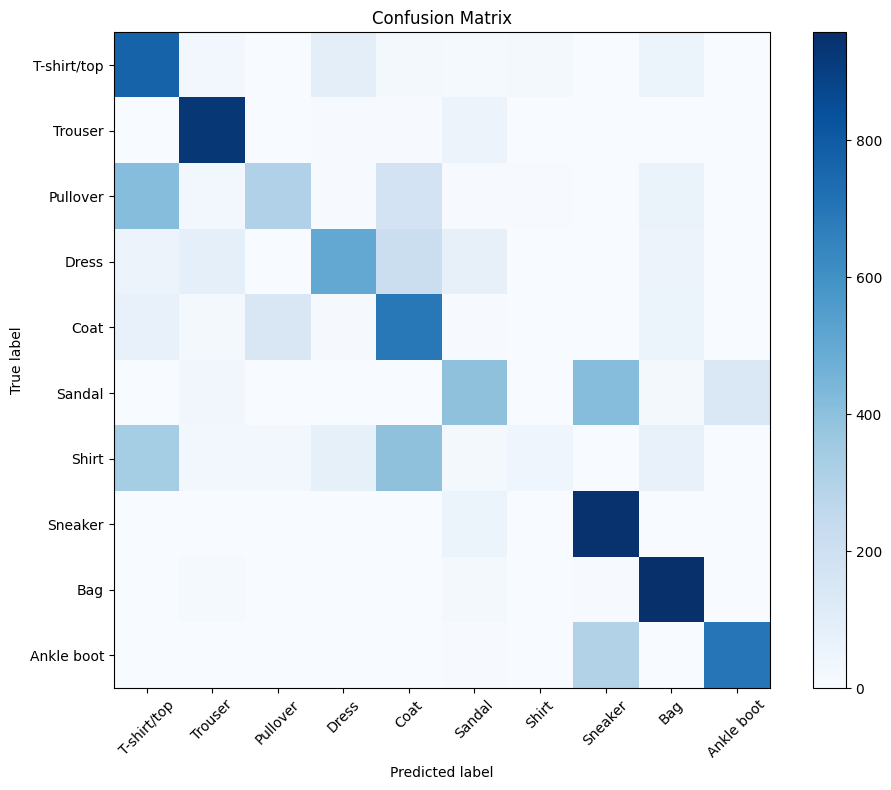

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_true, y_pred = [], []

# Build text embeddings once (outside the loop)
text_feats = get_text_embeddings(CLASS_NAMES)

for pixel_values, labels in test_loader:
    image_feats = get_image_embeddings(pixel_values)
    similarity  = get_cosine_similarity(image_feats, text_feats)
    preds       = get_predictions(similarity)
    y_pred.extend(preds)
    y_true.extend(labels.numpy())

# Report accuracy
print(f"Accuracy: {accuracy_score(y_true, y_pred):.2%}")


# Report the confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Report confusion matrix
plot_confusion_matrix(y_true, y_pred, CLASS_NAMES)

Reflection: Consider the results. How does the performance of this zero-shot baseline compare to the CNN you trained in Assignment 1? What are the strengths and weaknesses of this approach?

Zero-Shot CLIP (baseline) model on Fashion-MNIST had 63% accuracy with bare class names. 
A CNN model trained directly on Fashion-MNIST in Assignment 1 achieved around 90%. So the supervised CNN wins by a meaningful margin.

Strengths of Zero-Shot CLIP
1) We don’t need labelled training data - CLIP can handle new classification task instantly by changing the class name prompts
2) Generalizes across domains - As CLIP is trained on hundreds of millions of web-image - text pairs, it has broader knowledge
3) Flexible prompting - we can readjust CLIP model to classify with only rewording the prompts and there is no need to adjust the weights

Weakness of Zero-Shot CLIP
1) Fashion-MNIST dataset consists of images that are small, greyscale and low-resolution which is different to CLIP's training data. This can hurt performance of the model
2) Choice of Class Name  - choice of class name can impact results, while in CNN, the model learns directly from the images
3) Computationally heavy - CLIP is a large transformer model, CNN is cheaper to run comparatively

## Improving Zero-Shot Classification with Prompt Engineering

In the previous section, we directly used the class names as text prompts for zero-shot classification. However, we can often improve performance by crafting more descriptive prompts that better capture the visual characteristics of each class. For example, instead of just "T-shirt/top", we could use "a photo of a T-shirt" or "a photo of a top". This additional context can help the model make more accurate predictions.

In this section, we will experiment with more detailed prompts for each class to see if we can improve the zero-shot classification performance. You should:

- [ ] Create a list of improved prompts for each class. For example, instead of just "T-shirt/top", you could use "a photo of a T-shirt" or "a photo of a top".
- [ ] Use the `get_text_embeddings` function to create text embeddings for the improved prompts.
- [ ] Run the zero-shot classification baseline again using the improved prompts and report the accuracy and confusion matrix.

Note: Take advantage of the confusion matrix above. If two classes are often confused, consider how you might improve the prompts to help the model distinguish them better.

The aim for this section is for you to improve the performance of the model. However, if you find that the performance does not improve significantly, you can still reflect on the process and consider how you might further refine the prompts with more effort.

Accuracy (bare class names):     62.40%
Accuracy (improved prompts):     64.78%


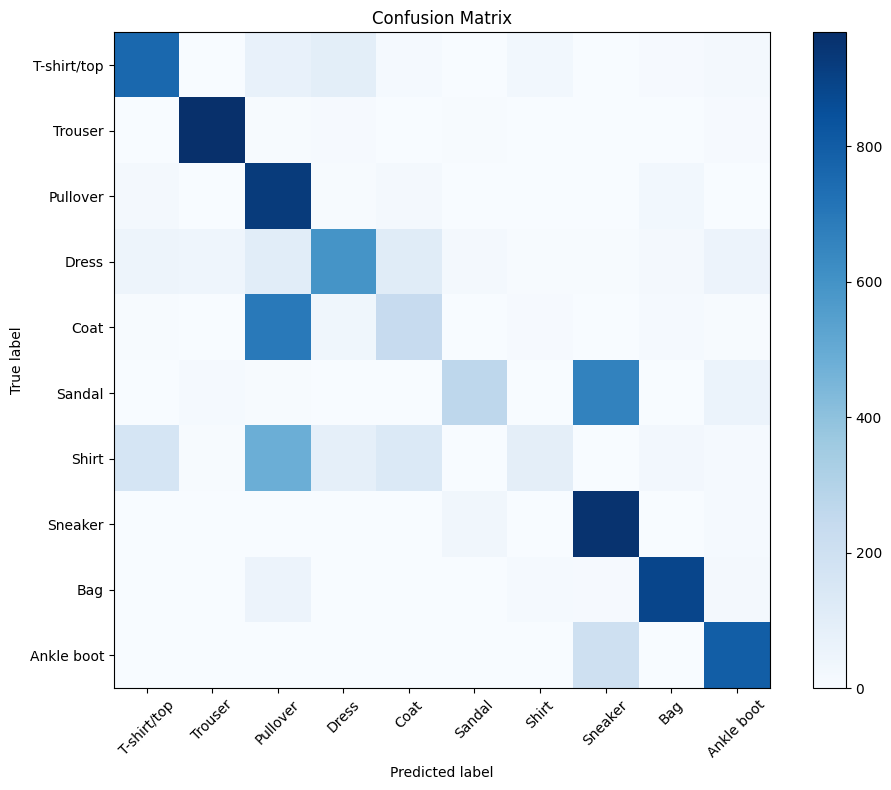

In [17]:
IMPROVED_PROMPTS = [
    "a photo of a t-shirt or casual top with short sleeves",           # T-shirt/top
    "a photo of a pair of trousers or pants with two legs",            # Trouser
    "a photo of a pullover sweater or knitted jumper with long sleeves ", # Pullover
    "a photo of a dress or skirt, a one-piece garment for women",      # Dress
    "a photo of a coat or long jacket with buttons",                   # Coat
    "a photo of a sandal, an open-toed summer shoe with straps",       # Sandal
    "a photo of a shirt with a collar and buttons down the front",     # Shirt
    "a photo of a sneaker or sports trainer, a lace-up athletic shoe", # Sneaker
    "a photo of a handbag or purse with handles",                      # Bag
    "a photo of an ankle boot, a short boot covering the ankle",       # Ankle boot
]

# Get improved text embeddings
text_feats_improved = get_text_embeddings(IMPROVED_PROMPTS)

# Run inference with improved prompts
y_true_imp, y_pred_imp = [], []

for pixel_values, labels in test_loader:
    image_feats = get_image_embeddings(pixel_values)
    similarity  = get_cosine_similarity(image_feats, text_feats_improved)
    preds       = get_predictions(similarity)
    y_pred_imp.extend(preds)
    y_true_imp.extend(labels.numpy())

# Report accuracy
print(f"Accuracy (bare class names):     {accuracy_score(y_true, y_pred):.2%}")
print(f"Accuracy (improved prompts):     {accuracy_score(y_true_imp, y_pred_imp):.2%}")

# Report confusion matrix
plot_confusion_matrix(y_true_imp, y_pred_imp, CLASS_NAMES)

Reflection: How did your detailed prompts affect the zero-shot classification performance? Did you see a significant improvement compared to the baseline? What insights did you gain about the model's understanding of the classes? Do you think that with more effort you could further improve the performance? If so, how?

Even with better prompts, we see that our accuracy gains are modest (from 62.4% --> 64.8%). 

This is due the domain gap, as Fashion-MNIST's greyscale, low-resolution images are very different from the natural photos CLIP was pretrained on. 

Prompt engineering helps CLIP's text encoder produce better-aligned embeddings, but it cannot compensate for the image encoder struggling with the visual domain. 

Large gains would require fine-tuning CLIP on some labelled Fashion-MNIST examples.

## Visualizing Image Embeddings with UMAP

To better understand how the model perceives the different classes, we can visualize the image embeddings using UMAP (Uniform Manifold Approximation and Projection). UMAP is a dimensionality reduction technique that helps us see how similar or dissimilar the embeddings are in a lower-dimensional space.

By visualizing the embeddings, we can gain insights into how well the model can distinguish certain images, even without considering the text prompts. This can help us identify clusters of similar images and see if there are any overlaps between classes.

You should:

- [ ] Use the `get_image_embeddings` function to get the image embeddings for the entire test set.
- [ ] Use UMAP to reduce the dimensionality of the image embeddings to 2D.
- [ ] Plot the 2D embeddings, coloring each point by its true class label.

You may need to install the `umap-learn` library if you haven't already. You can do this by running `pip install umap-learn`.

In [ ]:
# Uncomment the following line to install UMAP if you haven't already
# !pip install umap-learn

/Users/grookey/Documents/UofT/deep_learning/assignment2/deep_learning/deep-learning-env/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/grookey/Documents/UofT/deep_learning/assignment2/deep_learning/deep-learning-env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/var/folders/6g/b_w5cpzd14d2p1kb4j55qd4c0000gn/T/ipykernel_43195/124194012.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap("tab10", len(CLASS_NAMES))


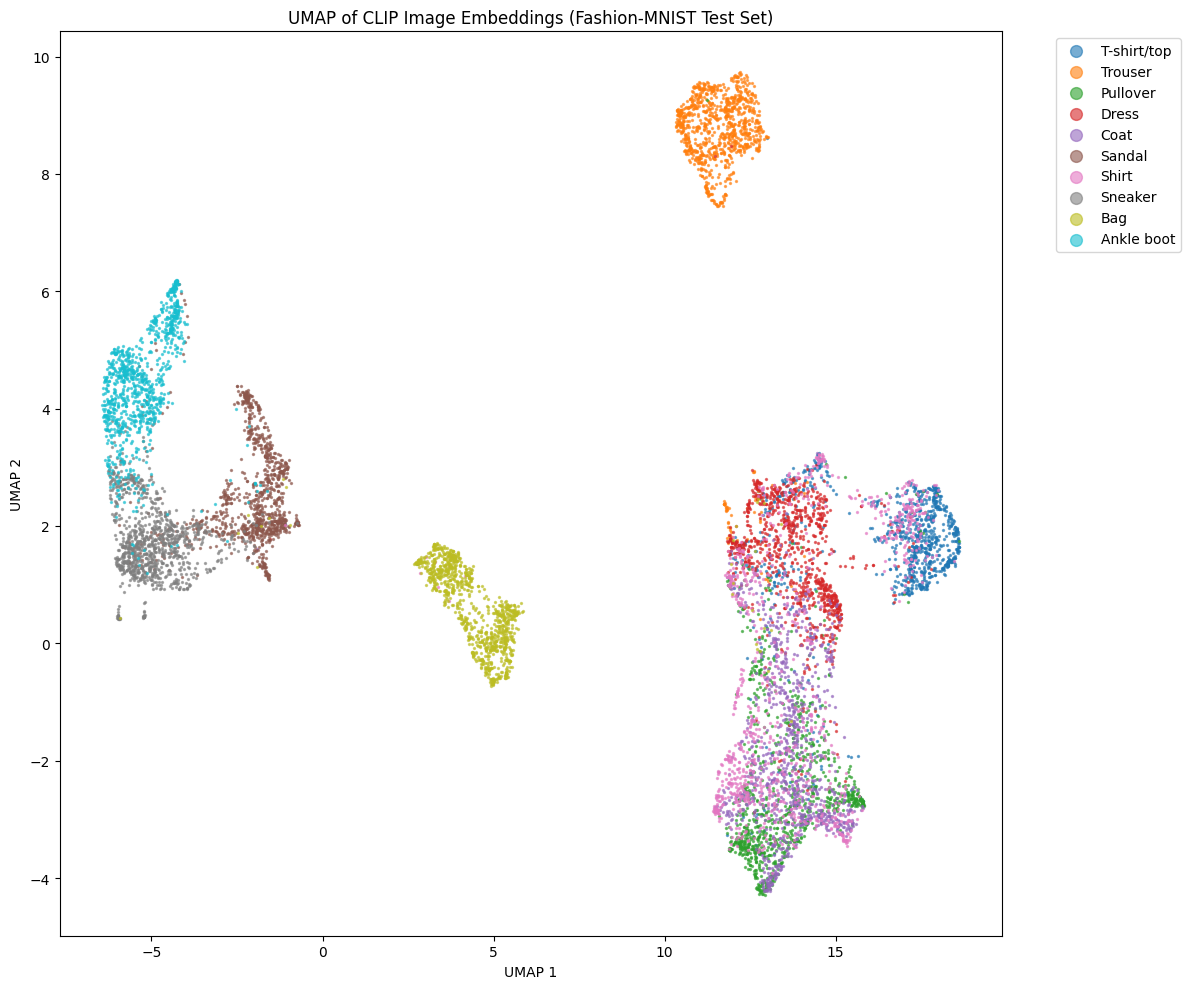

In [ ]:
from umap import UMAP
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Collect image embeddings
# ------------------------------------------------------------
all_img_emb = []
all_labels  = []

for pixel_values, labels in test_loader:
    image_feats = get_image_embeddings(pixel_values)
    all_img_emb.append(image_feats.cpu().numpy())
    all_labels.extend(labels.numpy())

all_img_emb = np.concatenate(all_img_emb, axis=0)  # (10000, D)
all_labels  = np.array(all_labels)                  # (10000,)

# ------------------------------------------------------------
# 2. Fit UMAP
# ------------------------------------------------------------
reducer   = UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(all_img_emb)       # (10000, 2)

# ------------------------------------------------------------
# 3. Plot coloured by ground-truth label
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 10))

palette = plt.cm.get_cmap("tab10", len(CLASS_NAMES))

for class_idx, class_name in enumerate(CLASS_NAMES):
    mask = all_labels == class_idx
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        s=2,
        color=palette(class_idx),
        label=class_name,
        alpha=0.6,
    )

ax.legend(markerscale=6, bbox_to_anchor=(1.05, 1), loc="upper left")
ax.set_title("UMAP of CLIP Image Embeddings (Fashion-MNIST Test Set)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.show()

Reflection on UMAP
From the UMAP plot we observe:

Easy classes: Trouser and Bag forms tight, well-separated clusters. This is because their silhouettes are so distinct that CLIP has no trouble embedding them far from everything else. 

Hard classes: Shirt, T-shirt/top, Pullover, and Coat cluster together in a messy overlapping region, which directly mirrors the confusion matrix errors. 
This is because they are all upper-body garments with similar shapes at low resolution.
Sneaker and Ankle boot also overlap somewhat, though less severely than the tops.
Dress and Sandal are have a lot of overlap with little separation.

The UMAP embeddings allow us to see how separable or non-separable different classes are with our specific model. If two specific images are very similar, then they will be placed near each other on this graph. 

Reflection: Do you notice any challenges in distinguishing images based on this figure? Are there any types of clothing in the dataset which the model has no trouble distinguishing from the others?

## Mini-Experiment

In this section, you will conduct a mini-experiment of your choice to further explore the capabilities of zero-shot classification with transformers. This can be anything you'd like, but here are some ideas to get you started.

### A. Alternative Model

So far we have been utilizing OpenAI's CLIP model for zero-shot classification. However, there are many other vision–language models available in the `transformers` library that you can experiment with. For example, there are larger CLIP models such as [clip-vit-large-patch14](https://huggingface.co/openai/clip-vit-large-patch14), and open-source versions such as [laion/CLIP-ViT-B-32-laion2B-s34B-b79K](https://huggingface.co/laion/CLIP-ViT-B-32-laion2B-s34B-b79K). You can also search huggingface [here](https://huggingface.co/models?sort=trending&search=clip) to find other models that might be suitable for zero-shot classification.

You can try using a different model to see if it improves the zero-shot classification performance. You should:
- [ ] Load a different model and processor from the `transformers` library.
- [ ] Run the zero-shot classification baseline with the new model and report the accuracy and confusion matrix.
- [ ] Reflect on the performance of the new model compared to the original CLIP model
  - How does the new model perform compared to the original CLIP model?
  - Do you notice any differences in the types of errors made by the new model?

### B. Multiple-Description Classification

Another interesting experiment is to explore multiple-description classification. *This involves providing multiple text prompts for each class, allowing the model to choose the most relevant one. For example, instead of just "T-shirt/top", you could provide "a photo of a T-shirt", "a photo of a top", and "a photo of a shirt". This can help the model better understand the class and increases the likelihood of a correct prediction. You should:

- [ ] Create a list of multiple prompts for each class.
- [ ] Use the `get_text_embeddings` function to create text embeddings for the multiple prompts.
- [ ] Run the zero-shot classification baseline again using the multiple prompts and report the accuracy and confusion matrix.
- [ ] Consider the model to be correct if it guesses *any* of the prompts belonging to the correct class.

### C. Top-K Classification

In some classification tasks, it can be useful to consider if the right answer is among the top K (e.g. top 3) predictions. This can be particularly useful in cases where the model is uncertain or when there are multiple similar classes. You should:

- [ ] Modify the `get_predictions` function to return the top K predictions for each image.
- [ ] Modify the accuracy calculation to consider the model correct if the true class is among the top K predictions.
- [ ] Report the accuracy and confusion matrix for the top K predictions. Report at least two different values of K (e.g. K=2 and K=4).

### D. Other Ideas

You are welcome to come up with your own mini-experiment! Explain your idea in the report and implement it. Did it work as you expected? What did you learn from it?

Accuracy (bare class names):        62.40%
Accuracy (improved single prompts): 64.78%
Accuracy (multi-description):       60.55%


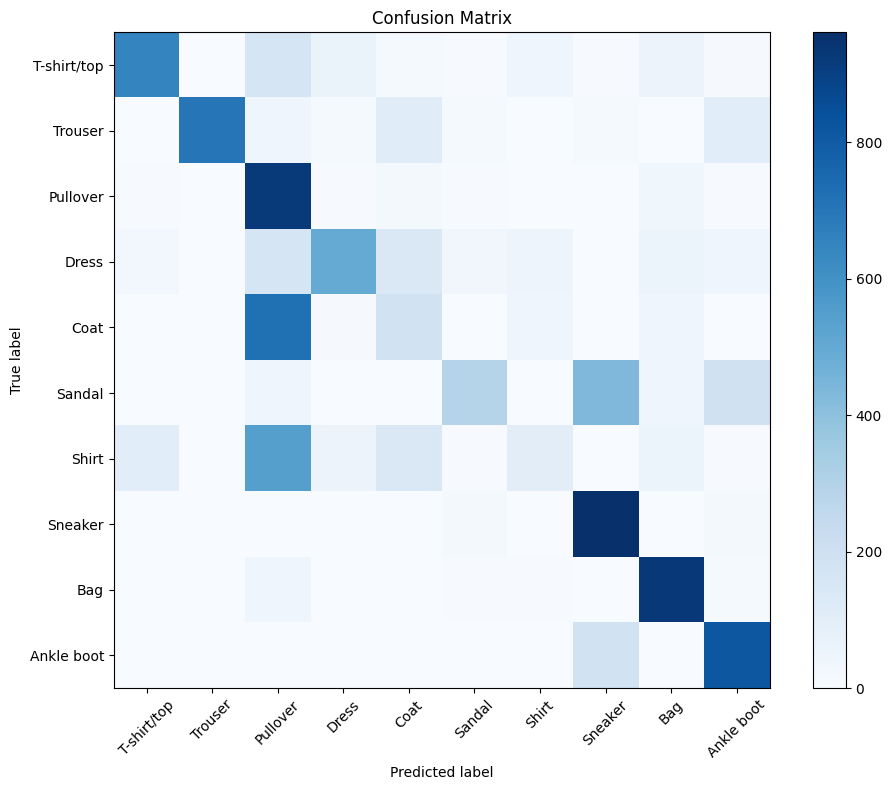

In [21]:
# Attempting Option B. Multiple-Description Classification
# Multiple prompts per class

MULTI_PROMPTS = {
    "T-shirt/top": [
        "a photo of a t-shirt",
        "a photo of a casual top",
        "a photo of a short-sleeved shirt",
    ],
    "Trouser": [
        "a photo of trousers",
        "a photo of a pair of pants",
        "a photo of jeans",
    ],
    "Pullover": [
        "a photo of a pullover",
        "a photo of a knitted sweater",
        "a photo of a jumper",
    ],
    "Dress": [
        "a photo of a dress",
        "a photo of a one-piece dress",
        "a photo of a skirt dress",
    ],
    "Coat": [
        "a photo of a coat",
        "a photo of a long jacket",
        "a photo of an overcoat with buttons",
    ],
    "Sandal": [
        "a photo of a sandal",
        "a photo of an open-toed sandal with straps",
        "a photo of a summer sandal",
    ],
    "Shirt": [
        "a photo of a shirt with a collar",
        "a photo of a button-down shirt",
        "a photo of a dress shirt",
    ],
    "Sneaker": [
        "a photo of a sneaker",
        "a photo of a sports trainer",
        "a photo of a lace-up athletic shoe",
    ],
    "Bag": [
        "a photo of a handbag",
        "a photo of a purse with handles",
        "a photo of a tote bag",
    ],
    "Ankle boot": [
        "a photo of an ankle boot",
        "a photo of a short boot covering the ankle",
        "a photo of a chelsea boot",
    ],
}

# Flatten prompts and build a mapping from prompt index → class index
flat_prompts   = []
prompt_to_class = []

for class_idx, class_name in enumerate(CLASS_NAMES):
    for prompt in MULTI_PROMPTS[class_name]:
        flat_prompts.append(prompt)
        prompt_to_class.append(class_idx)

prompt_to_class = np.array(prompt_to_class)

# Get embeddings for all prompts
text_feats_multi = get_text_embeddings(flat_prompts)  # (num_prompts, D)

# Inference: pick the class whose *best* prompt wins
y_true_multi, y_pred_multi = [], []

for pixel_values, labels in test_loader:
    image_feats = get_image_embeddings(pixel_values)         # (N, D)
    similarity  = get_cosine_similarity(image_feats, text_feats_multi)  # (N, num_prompts)

    # For each image, find the prompt with highest similarity
    best_prompt_idx = np.argmax(similarity, axis=1)          # (N,)
    # Map that prompt back to its class
    preds = prompt_to_class[best_prompt_idx]                 # (N,)

    y_pred_multi.extend(preds)
    y_true_multi.extend(labels.numpy())

# Results
print(f"Accuracy (bare class names):        {accuracy_score(y_true, y_pred):.2%}")
print(f"Accuracy (improved single prompts): {accuracy_score(y_true_imp, y_pred_imp):.2%}")
print(f"Accuracy (multi-description):       {accuracy_score(y_true_multi, y_pred_multi):.2%}")

plot_confusion_matrix(y_true_multi, y_pred_multi, CLASS_NAMES)

In [ ]:
# Attempting Option C. Top-K Classification

def get_topk_predictions(similarity: np.ndarray, k: int) -> np.ndarray:
    """Returns indices of top-k most similar classes for each image. Shape: (N, k)."""
    return np.argsort(similarity, axis=1)[:, -k:]  # highest k scores

def topk_accuracy(y_true, similarity, k):
    topk = get_topk_predictions(similarity, k)
    correct = sum(
        true in topk_row
        for true, topk_row in zip(y_true, topk)
    )
    return correct / len(y_true)

# Collect similarities for the whole test set
text_feats_base = get_text_embeddings(CLASS_NAMES)

all_sims, all_labels_k = [], []

for pixel_values, labels in test_loader:
    image_feats = get_image_embeddings(pixel_values)
    similarity  = get_cosine_similarity(image_feats, text_feats_base)
    all_sims.append(similarity)
    all_labels_k.extend(labels.numpy())

all_sims = np.concatenate(all_sims, axis=0)  # (10000, 10)

# Results
for k in [1, 2, 3, 4, 5]:
    acc = topk_accuracy(all_labels_k, all_sims, k)
    print(f"Top-{k} accuracy: {acc:.2%}")

Top-1 accuracy: 62.40%
Top-2 accuracy: 81.46%
Top-3 accuracy: 88.23%
Top-4 accuracy: 92.45%
Top-5 accuracy: 95.36%


### Short Report

In this section, you will write a short report summarizing your findings from the mini-experiment. The report should include the following sections:

- **Introduction**: Briefly describe the mini-experiment you conducted and its objectives.
- **Methodology**: Explain the steps you took to conduct the experiment, including any modifications you made to the code or model.
- **Results**: Present the results of your experiment.
- **Discussion**: Reflect on the performance of the model and the implications of your findings. Consider the strengths and weaknesses of zero-shot transformers versus a trained CNN.

**Short Report**

**Introduction**

We attempted two mini-experiments to further explore zero-shot classification with CLIP on Fashion-MNIST. 

Experiment B tested whether providing multiple text descriptions per class improves accuracy by giving the model more ways to match an image to its correct label. 

Experiment C explored top-K accuracy, asking whether the correct class appears within the top K predictions, rather than strictly requiring rank-1 correctness.

**Methodology**

Experiment B – Multiple-Description Classification:
Three distinct text prompts were written for each of the 10 classes (30 prompts total). All prompts were embedded using get_text_embeddings, producing a (30, D) similarity matrix per batch. 
Each image was assigned the class whose best-matching prompt had the highest cosine similarity, using a prompt_to_class mapping array.

Experiment C – Top-K Classification: T
he get_predictions function was extended to get_topk_predictions, which uses np.argsort to return the K highest-similarity class indices per image. 
A topk_accuracy function then checks whether the true label appears anywhere in the top-K set. 
This was evaluated for K = 1, 2, 3, 4, and 5 using the base class name embeddings.

**Results**
Method                                             Accuracy 
Bare class names (baseline)                         62.40%
Improved single prompts                             64.78%
Multi-Description (Experiment B)                    60.55%
Top-K Classification Top-1 (Experiment C)           62.40%
Top-K Classification Top-2 (Experiment C)           81.46%
Top-K Classification Top-3 (Experiment C)           88.23%
Top-K Classification Top-4 (Experiment C)           92.45%
Top-K Classification Top-5 (Experiment C)           95.36%

**Discussion**

*Experiment B* showed that multiple descriptions offers no real improvement — though the model has alternative phrasings, particularly for ambiguous classes like Shirt vs T-shirt/top. 
A likely reason is that some prompts for one class (e.g. "a photo of a short-sleeved shirt" for T-shirt/top) are semantically close to another class (Shirt), causing cross-class confusion. 
However, gains are limited because the bottleneck is the image encoder's difficulty with greyscale, low-resolution inputs, not because of the text encoder.

*Experiment C* Works much better, in our findings: there is a a large jump in accuracy from Top-1 to Top-2 (62% to 81%), then accuracy improves futher from Top-2 to Top-5 (81% to 95%).

This implies CLIP's errors are nearly always a near-miss between two visually similar classes rather than a random mistake. The correct class is almost always the model's second or third choice. 

Overall, zero-shot CLIP is flexible and requires no labelled data, but falls short of a trained CNN due to the domain mismatch between Fashion-MNIST and CLIP's web-image pretraining. Fine-tuning CLIP's image encoder on even a small set of Fashion-MNIST examples would likely close this gap substantially.



🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 02/11/2025`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb)
    * The Lab 4 notebook (labs/lab_4.ipynb)
    * The Lab 5 notebook (labs/lab_5.ipynb)
    * The Lab 6 notebook (labs/lab_6.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.